In [2]:
path = '/home/world-models/ogbench/data_gen_scripts/data/visual-scene-play-v0.npz'

In [3]:
import numpy as np

data = np.load(path)

for k in data.files:
    print(f'{k:15s} shape={data[k].shape}  dtype={data[k].dtype}')

obs, acts, terms = data['observations'], data['actions'], data['terminals']
print('first obs:', obs[0])
print('first action:', acts[0])   # 5-dim: arm x, y, z, yaw, gripper, each in [-1, 1]

# Episode boundaries: terminals is True on the last step of each episode
ends = np.where(terms)[0]
print('num episodes:', len(ends), '| episode lengths:', np.diff(np.r_[-1, ends])[:5])

observations    shape=(2002000, 64, 64, 3)  dtype=uint8
actions         shape=(2002000, 5)  dtype=float32
terminals       shape=(2002000,)  dtype=bool
qpos            shape=(2002000, 25)  dtype=float32
qvel            shape=(2002000, 24)  dtype=float32
button_states   shape=(2002000, 2)  dtype=int64
first obs: [[[ 54  62  88]
  [ 54  62  88]
  [ 54  63  88]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[ 54  63  88]
  [ 54  63  88]
  [ 54  63  88]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[ 54  63  88]
  [ 54  63  89]
  [ 54  63  89]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 ...

 [[ 29  42  60]
  [ 29  42  60]
  [ 31  42  60]
  ...
  [ 57  68  95]
  [ 56  68  95]
  [ 56  67  94]]

 [[ 29  42  60]
  [ 30  42  60]
  [ 30  42  60]
  ...
  [ 57  68  95]
  [ 57  68  95]
  [ 56  68  95]]

 [[ 30  42  60]
  [ 30  42  60]
  [ 30  42  60]
  ...
  [ 57  68  95]
  [ 57  68  95]
  [ 57  68  95]]]
first action: [-0.01036561 -0.00320012 -0.04242945  0.0232

In [14]:
for k in data.files:
    image = data[k]
    break
image.shape

(10010, 64, 64, 3)

In [1]:
import numpy as np, imageio
from IPython.display import Video
path = '/home/world-models/ogbench/data_gen_scripts/data/visual-scene-play-v0.npz'
data = np.load(path)
images = data['observations']                      # (10010, 64, 64, 3)

end = np.where(data['terminals'])[0][0] + 1         # first episode = steps 0..1000
ep0 = images[:end]

# 64x64 is tiny on screen; upscale 4x by repeating pixels
ep0_big = ep0.repeat(4, axis=1).repeat(4, axis=2)  # (1001, 256, 256, 3)


imageio.mimsave('ep0.mp4', ep0_big, fps=30)         # needs: pip install "imageio[ffmpeg]"
Video('ep0.mp4', embed=True)

In [19]:
print(ep0_big.shape)

(1001, 256, 256, 3)


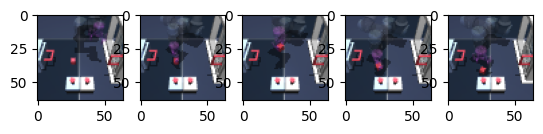

In [16]:
import matplotlib.pyplot as plt
# subplot first 5 in row
frame_skip = 20
plt.subplot(1, 5, 1)
plt.imshow(image[0, ...])

plt.subplot(1, 5, 2)
plt.imshow(image[frame_skip, ...])


plt.subplot(1, 5, 3)
plt.imshow(image[frame_skip * 2, ...])


plt.subplot(1, 5, 4)
plt.imshow(image[frame_skip * 3, ...])

plt.subplot(1, 5, 5)
plt.imshow(image[frame_skip * 4, ...])